## Regularization : Lasso and Ridge

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd

In [ ]:
insurance_data = pd.read_csv("insurance.csv")

In [ ]:
X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X["smoker"] = X["smoker"].map({
    "yes":1,
    "no":0
})
X["sex"] = X["sex"].map({
    "female":1,
    "male":0
})

X = pd.get_dummies(X, columns=["region"] , drop_first=True , dtype=int)

#interaction feature
X["age_smoker"] = X["age"] * X["smoker"]

X["bmi_smoker"] = X["bmi"] * X["smoker"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2, random_state=42
)

## Part 1 : Apply Lasso regression (manually)

mse for alpha = 0.001 :  20922599.871035974
mse for alpha = 0.1 :  20921803.69843139
mse for alpha = 1 :  20914832.635089148
mse for alpha = 2 :  20908106.779954527
mse for alpha = 5 :  20890881.000633504
mse for alpha = 10 :  20872844.794796687
mse for alpha = 20 :  20877828.53237883
mse for alpha = 30 :  20937537.13393977
mse for alpha = 40 :  21046489.293890774
mse for alpha = 50 :  21196929.869608898
mse for alpha = 100 :  22423172.68602322


<Axes: >

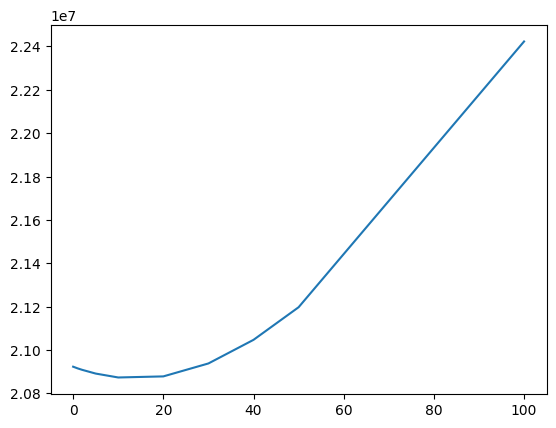

In [ ]:
alphas = [0.001 , 0.1 , 1,2,5,10,20,30,40,50,100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha=a)

    lasso_model.fit(X_train, y_train)

    y_pred = lasso_model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred) 



    print(f"mse for alpha = {a} : ", mse)

    mses.append(mse)



import seaborn as sns


sns.lineplot(x = alphas, y=mses)


 this is not the way we apply lasso regularization  , where are finding the alpha manually

## Part 2 : LassoCV , RidgeCV

In [ ]:
from sklearn.linear_model import LassoCV

a = [0.001 , 0.1 , 1,2,5,10,20,30,40,50,100]

lasso_cv_model = LassoCV(
    alphas= a, 
    cv= 5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("best value for alpha : ", lasso_cv_model.alpha_)



y_pred = lasso_cv_model.predict(X_test)

mse= mean_squared_error(y_test, y_pred)
r2_value = r2_score(y_test, y_pred)

print("mean squared value : ", mse)
print("r2 value : ", r2_value)

best value for alpha :  0.001
mean squared value :  20922599.871035974
r2 value :  0.8652317499151698
